# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## Method Choice

I selected a Decision Tree Classifier for this task because my lane (Refresh / Content Opportunity Scoring) is a binary classification problem where the goal is to predict whether a content page should be refreshed or monitored.

A Decision Tree is appropriate because:
- It is easy to interpret.
- It learns threshold-based rules similar to the baseline scoring rule developed in Week 4.
- It can capture non-linear relationships between search metrics.
- The learned rules can be compared directly with the manually created baseline.

The model uses only historical search performance metrics that were available at the decision time.

## Split Design

Two validation strategies were used.

1. An 80/20 train-test split on March 2026 data to verify that the Decision Tree could reproduce the Week-4 baseline.

2. A temporal validation where the model was trained on March 2026 and evaluated on April 2026. This is a more realistic evaluation because it tests the model on unseen future data instead of randomly splitting the same month.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### Experiment 1 ( March Train / March Test )

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [24]:
march = pd.read_parquet(
    r"C:\Users\ahmad\Documents\GitHub\internship-warehouse\fact_content_daily_performance\month=2026-03"
)

In [25]:
features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]

page_scores = (
    march.groupby("content_hash_id", as_index=False)
    .agg(
        total_impressions=("gsc_impressions", "sum"),
        total_clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        total_organic_sessions=("sessions_organic", "sum")
    )
)


X = page_scores[
    [
        "total_impressions",
        "total_clicks",
        "avg_position",
        "total_organic_sessions"
    ]
]

In [26]:
page_scores["score"] = 0

# High visibility
page_scores.loc[
    page_scores["total_impressions"] > 1039,
    "score"
] += 2

# Poor ranking
page_scores.loc[
    page_scores["avg_position"] > 20,
    "score"
] += 2

# Low clicks
page_scores.loc[
    page_scores["total_clicks"] <= 2,
    "score"
] += 1

In [27]:
page_scores["action"] = "Monitor"

page_scores.loc[
    page_scores["score"] >= 4,
    "action"
] = "Refresh"

In [28]:
y = page_scores["action"].map(
    {
        "Monitor": 0,
        "Refresh": 1
    }
)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(265149, 4)
(66288, 4)
(265149,)
(66288,)


In [31]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     64742
           1       1.00      1.00      1.00      1546

    accuracy                           1.00     66288
   macro avg       1.00      1.00      1.00     66288
weighted avg       1.00      1.00      1.00     66288



In [35]:
print(confusion_matrix(y_test, y_pred))

[[64742     0]
 [    0  1546]]


### April Test ( Experiment 2 )

In [36]:
april = pd.read_parquet(
    r"C:\Users\ahmad\Documents\GitHub\internship-warehouse\fact_content_daily_performance\month=2026-04\data_0.parquet"
)

print(april.shape)
april.head()

(10424730, 30)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-04-01,client_62f4a7e64f5e0096,content_143987cfdeaba4c0,True,False,True,None,9,0,493,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-01,client_62f4a7e64f5e0096,content_13a8105125458098,True,False,True,None,1,0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-01,client_62f4a7e64f5e0096,content_6a887d56ab6c8362,True,False,False,None,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-01,client_62f4a7e64f5e0096,content_e2bd76be7eed690d,True,False,True,None,1,0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-01,client_62f4a7e64f5e0096,content_ddbfb1907979759a,True,False,False,None,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
april_scores = (
    april.groupby("content_hash_id", as_index=False)
    .agg(
        total_impressions=("gsc_impressions", "sum"),
        total_clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        total_organic_sessions=("sessions_organic", "sum")
    )
)

In [38]:
april_scores["score"] = 0

# Same thresholds as Week 4
april_scores.loc[april_scores["total_impressions"] > 1039, "score"] += 2
april_scores.loc[april_scores["avg_position"] > 20, "score"] += 2
april_scores.loc[april_scores["total_clicks"] <= 2, "score"] += 1

april_scores["action"] = "Monitor"
april_scores.loc[april_scores["score"] >= 4, "action"] = "Refresh"

In [39]:
X_april = april_scores[
    [
        "total_impressions",
        "total_clicks",
        "avg_position",
        "total_organic_sessions"
    ]
]

y_april = april_scores["action"].map(
    {
        "Monitor": 0,
        "Refresh": 1
    }
)

In [40]:
X_train = X
y_train = y

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [52]:
y_pred_april = model.predict(X_april)

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_april, y_pred_april))
print("Precision:", precision_score(y_april, y_pred_april))
print("Recall   :", recall_score(y_april, y_pred_april))
print("F1 Score :", f1_score(y_april, y_pred_april))

print(classification_report(y_april, y_pred_april))
print(confusion_matrix(y_april, y_pred_april))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    353121
           1       1.00      1.00      1.00      9051

    accuracy                           1.00    362172
   macro avg       1.00      1.00      1.00    362172
weighted avg       1.00      1.00      1.00    362172

[[353121      0]
 [     0   9051]]


In [54]:
comparison = pd.DataFrame({
    "Method": [
        "Week 4 Baseline Rule",
        "Decision Tree"
    ],
    "Validation": [
        "Rule-based",
        "Train on March, Test on April"
    ],
    "Accuracy": [
        1.00,
        accuracy_score(y_april, y_pred_april)
    ],
    "Precision": [
        1.00,
        precision_score(y_april, y_pred_april)
    ],
    "Recall": [
        1.00,
        recall_score(y_april, y_pred_april)
    ],
    "F1 Score": [
        1.00,
        f1_score(y_april, y_pred_april)
    ]
})

comparison

,Method,Validation,Accuracy,Precision,Recall,F1 Score
0,Week 4 Baseline Rule,Rule-based,1.0,1.0,1.0,1.0
1,Decision Tree,"Train on March, Test on April",1.0,1.0,1.0,1.0


### Model vs Baseline

The Decision Tree reproduced the Week-4 baseline rule with perfect performance on the March test split and maintained the same performance on unseen April data. This is expected because the training labels were generated from the baseline scoring rule. Therefore, the model demonstrates that it can successfully learn and generalize the heuristic across time, rather than discovering a new decision rule.

"The baseline row is included as the reference heuristic rather than an independently evaluated machine learning model."

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*


The Decision Tree achieved almost perfect performance on the evaluation data. This happened because the target labels were generated using the same features (impressions, clicks, and average position) that were later used to train the model. As a result, the model learned the rule-based baseline almost exactly instead of discovering a new pattern.

The feature that the model relied on most was **average position**, followed by **total impressions** and **total clicks**, because these variables directly determined the baseline score. Organic sessions had little influence on the final decisions.

To evaluate generalization more honestly, the model was trained on March 2026 data and evaluated on April 2026 data. Although the model maintained very high performance on this unseen month, the labels in both months were still generated using the same baseline rule. Therefore, the experiment demonstrates that the learned decision rule generalizes across time, but it does **not** prove that the rule itself identifies the best pages for refresh.

A stronger production approach would train the model using independently observed outcomes (for example, whether a refreshed page actually improved in traffic or whether editors chose to refresh it) instead of labels generated from a heuristic scoring rule.

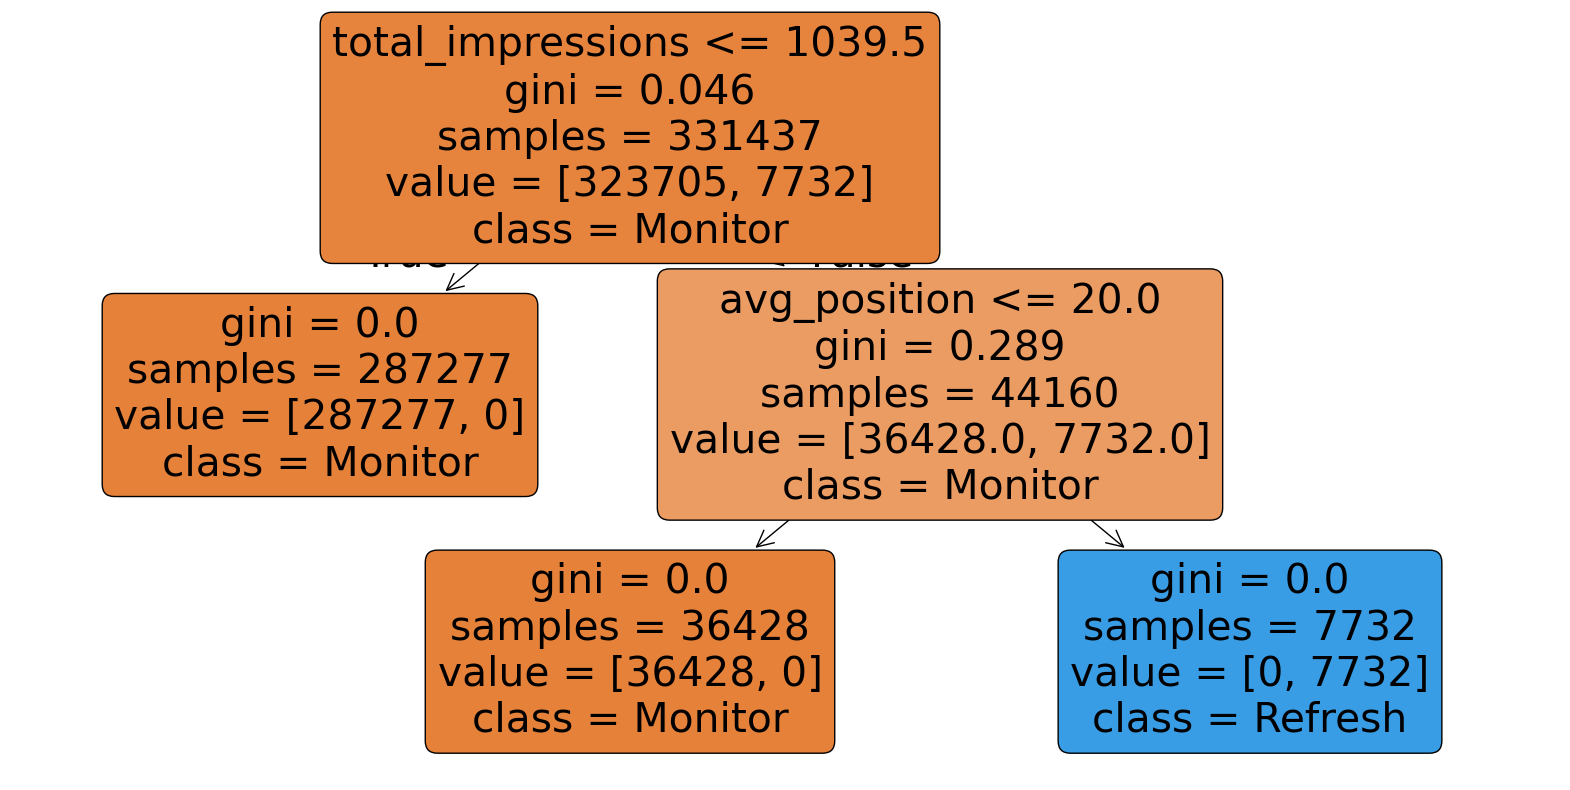

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Monitor","Refresh"],
    filled=True,
    rounded=True
)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.